# Network Meta-Analysis: Comparing Multiple Interventions Together

Conventional meta-analysis pools only **direct comparisons** of **two** interventions at a time. But in practice there are often multiple interventions—A, B, C, D—and **no single trial compares all of them pairwise**—some trials compare A vs B, others C vs D, still others A vs D... To learn "how much better D is than A", using only trials that directly compared A and D wastes the information carried by the indirect pathway "A vs B, B vs D". **Network meta-analysis (NMA)** puts the entire evidence network—direct + indirect—into a single model, simultaneously ranks all interventions, and provides **any-pairwise** pooled comparisons.

This notebook uses the frequentist **contrast-based GLS method**, which is the **exact equivalent** of the graph-theoretic `netmeta`: same point estimates, same variances, pure numpy/scipy implementation, no R, no MCMC. Multi-arm trials handled with **exact intra-cluster covariance** (shared baseline arm). We will walk through:

1. **Arm-level → contrast data**: compress study × treatment event/sample tables into log-ORs for each non-baseline arm vs baseline;
2. **Network meta pooling + league table**: estimate all treatments vs reference and a complete pairwise league table in one pass;
3. **Ranking**: P-score (frequentist SUCRA, closed-form) + rankogram/SUCRA;
4. **Inconsistency**: design × treatment global Q decomposition + node splitting (direct vs indirect conflict);
5. **Component NMA**: decompose composite interventions into additive components;
6. **Two plots**: network geometry + league table heatmap.

Key feature: the data form a **consistent network** with true log-odds A = −0.5, B = 0, C = 0.5, D = 1.0 (D vs A = **+1.5**)—we will see whether network estimation **recovers this true value** and confirms no direct/indirect conflict.

> **Comparison**: R `netmeta` (graph-theoretic frequentist) / `gemtc` (Bayesian) / `BUGSnet`.

In [1]:
import os
import sys

# 确保用的是本 worktree 里的 socialverse(而不是环境里 editable 安装指向的其它 checkout)
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 在 Jupyter cell 里没有 __file__,退回当前工作目录
    _HERE = os.path.abspath(os.getcwd())
_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "notebooks" else _HERE
if os.path.isdir(os.path.join(_ROOT, "socialverse")) and _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib
matplotlib.use("Agg")  # 无显示环境:图直接写文件
import matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
import numpy as np
import pandas as pd
from IPython.display import Image

import socialverse as sv
from socialverse import datasets as ds

# 让本 notebook 自绘的图也能显示中文标签
_CJK = ["PingFang SC", "Hiragino Sans GB", "Songti SC", "STHeiti",
        "Arial Unicode MS", "Noto Sans CJK SC", "Microsoft YaHei"]
_have = {f.name for f in _fm.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [c for c in _CJK if c in _have] + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("socialverse", sv.__version__)

socialverse 0.6.0


## 1. Data: Arm-level trials for four interventions A/B/C/D

Each row is an **arm**: in a given trial, an intervention has `events` occurrences among `n` total participants. A two-arm trial spans two rows (sharing `study`). This network has six pairwise comparisons (A-B, A-C, B-C, B-D, C-D, A-D), each with several trials, forming a **connected** evidence network. Since larger outcomes are "better" (higher event rate), the log-odds higher indicates stronger intervention; true values D (1.0) > C (0.5) > B (0) > A (−0.5).

In [2]:
net = ds.load_network_trials()
print(f"试验数 = {net['study'].nunique()},臂数 = {len(net)},处理 = {sorted(net['treat'].unique())}")
net.head(10)

试验数 = 26,臂数 = 52,处理 = ['A', 'B', 'C', 'D']


,study,treat,events,n
0,T01,A,79,194
1,T01,B,54,93
2,T02,A,35,82
3,T02,B,43,96
4,T03,A,99,235
5,T03,B,37,80
6,T04,A,35,102
7,T04,B,66,156
8,T05,A,65,167
9,T05,B,59,125


## 2. Arm-level → contrast data: sv.pp.nma_pairwise

**Problem solved**: network meta engines consume **contrasts**—"the log-OR of treat1 relative to treat2 in this study plus standard error"—not raw arm-level event counts. **Key assumption**: each study picks one baseline arm (first arm here), and all other arms contrast against it; in multi-arm trials, each contrast **shares the baseline arm's variance**, which is the source of intra-cluster covariance. **Steps**: `nma_pairwise` groups by `study=`/`treatment=`, takes binary `events=`/`n=` → calculates per-contrast log-OR, seTE, and records baseline arm variance `vbase`, writing to `models["nma_contrasts"]`.

In [3]:
study = sv.StudyState()
study.write("sources", "datasets", net)

sv.pp.nma_pairwise(study, study="study", treatment="treat", events="events", n="n")

contrasts = study.models["nma_contrasts"]
print(f"对比数 = {len(contrasts)}(效应量 = {contrasts['measure'].iloc[0]})")
contrasts[["studlab", "treat1", "treat2", "TE", "seTE"]].round(3).head(10)

对比数 = 26(效应量 = OR)


,studlab,treat1,treat2,TE,seTE
0,T01,B,A,0.701,0.256
1,T02,B,A,0.086,0.303
2,T03,B,A,0.167,0.260
3,T04,B,A,0.339,0.264
4,T05,B,A,0.338,0.239
5,T06,C,A,1.463,0.227
6,T07,C,A,0.634,0.214
7,T08,C,A,0.841,0.225
8,T09,C,B,0.387,0.253
9,T10,C,B,0.061,0.257


## 3. Network meta pooling: sv.tl.netmeta — rank all treatments at once

**Problem solved**: connect all contrasts above (direct evidence) through shared treatment nodes, perform **generalized least squares (GLS)**, simultaneously estimate each treatment vs reference effect—indirect evidence flows through the network automatically. **Key assumption**: network is connected, random effects (`comb='random'`) absorb between-study heterogeneity. **Steps**: construct design matrix X (contrasts × basic parameters), covariance V (with multi-arm intra-cluster covariance), GLS solves for β and vcov, then expand into a complete pairwise **league table**. Reference defaults to treatment A (alphabetically first)—exactly our true-value reference.

In [4]:
sv.tl.netmeta(study, reference="A", comb="random")
nma = study.models["nma"]

print(f"参照 = {nma['reference']}  ·  效应量 = {nma['sm']}(log-OR)  ·  模型 = {nma['model']}")
print(f"τ² = {nma['tau2']:.4f}   Q = {nma['Q']:.2f} (df={nma['df']}, p={nma['Q_pval']:.3f})   I² = {nma['I2']:.1f}%")
print()
print("各处理 vs 参照 A(应还原真值:B≈+0.5, C≈+1.0, D≈+1.5):")
for t, e in nma["effects"].items():
    print(f"  {t} vs A:  {e['vs_ref']:+.3f}  (SE {e['se']:.3f})")

参照 = A  ·  效应量 = OR(log-OR)  ·  模型 = random
τ² = 0.0692   Q = 48.34 (df=23, p=0.002)   I² = 52.4%

各处理 vs 参照 A(应还原真值:B≈+0.5, C≈+1.0, D≈+1.5):
  A vs A:  +0.000  (SE 0.000)
  B vs A:  +0.425  (SE 0.123)
  C vs A:  +0.861  (SE 0.130)
  D vs A:  +1.391  (SE 0.133)


The three non-reference treatments' estimates closely match the true differences (+0.5 for B, +1.0 for C, +1.5 for D)—the network combines direct + indirect evidence and successfully **recovers D vs A ≈ 1.5**. Below we reshape the league table into a matrix to see all pairwise comparisons.

In [5]:
tr = nma["treatments"]
league_mat = pd.DataFrame(index=tr, columns=tr, dtype=object)
for i in tr:
    for j in tr:
        if i == j:
            league_mat.loc[i, j] = "—"
        else:
            c = nma["league"][f"{i} vs {j}"]
            league_mat.loc[i, j] = f"{c['estimate']:+.2f} [{c['ci_lb']:+.2f},{c['ci_ub']:+.2f}]"
print("联赛表:行 vs 列 的 log-OR [95% CI]")
league_mat

联赛表:行 vs 列 的 log-OR [95% CI]


,A,B,C,D
A,—,"-0.43 [-0.67,-0.18]","-0.86 [-1.12,-0.60]","-1.39 [-1.65,-1.13]"
B,"+0.43 [+0.18,+0.67]",—,"-0.44 [-0.66,-0.21]","-0.97 [-1.20,-0.74]"
C,"+0.86 [+0.60,+1.12]","+0.44 [+0.21,+0.66]",—,"-0.53 [-0.77,-0.30]"
D,"+1.39 [+1.13,+1.65]","+0.97 [+0.74,+1.20]","+0.53 [+0.30,+0.77]",—


## 4. Ranking (I): sv.tl.netrank — P-score (frequentist SUCRA)

**Problem solved**: decision-makers want **rankings** of "which intervention is best," not just pairwise comparisons. **P-score** is the frequentist closed-form version of SUCRA: a treatment's **average probability of being superior to others**. **Key assumption**: clarify whether small values are good or bad—here higher event rate is better, so `small_values='undesirable'` (small log-odds are not ideal). **Steps**: for each pair of treatments, use normal tail probabilities to calculate "i is superior to k", then average over all k. P-score closer to 1 is better.

In [6]:
sv.tl.netrank(study, small_values="undesirable")
pscore = study.diagnostics["netrank"]["pscore"]
print("P-score 排名(越大越好,真优序 D>C>B>A):")
for t, s in pscore.items():
    print(f"  {t}:  {s:.3f}")

P-score 排名(越大越好,真优序 D>C>B>A):
  D:  1.000
  C:  0.667
  B:  0.333
  A:  0.000


## 5. Ranking (II): sv.tl.nma_rankogram — rankogram + SUCRA

**Problem solved**: P-score gives a scalar; **rankogram** provides finer distribution—each treatment's **probability of occupying each rank**. **Key assumption**: Monte Carlo sample from the multivariate normal (β, cov) of the network estimate, tabulate each treatment's rank in each sample. **Steps**: MVN sampling → rank treatments by log-odds in each sample → tabulate rank frequencies → SUCRA (area under rank distribution curve). Again declare `small_values='undesirable'`.

In [7]:
sv.tl.nma_rankogram(study, small_values="undesirable", nsim=5000, seed=42)
rk = study.diagnostics["rankogram"]
print("SUCRA(越大越好):")
for t, s in rk["SUCRA"].items():
    print(f"  {t}:  {s:.3f}")
print()
print("排序概率(行=处理,列=名次1..4;名次1=最好):")
pd.DataFrame(rk["rank_probabilities"], index=[f"名次{r}" for r in range(1, len(tr) + 1)]).T.round(3)

SUCRA(越大越好):
  D:  1.000
  C:  0.667
  B:  0.333
  A:  0.000

排序概率(行=处理,列=名次1..4;名次1=最好):


,名次1,名次2,名次3,名次4
A,0.0,0.0,0.0,1.0
B,0.0,0.0,1.0,0.0
C,0.0,1.0,0.0,0.0
D,1.0,0.0,0.0,0.0


## 6. Inconsistency (I): sv.tl.nma_inconsistency — design × treatment global Q decomposition

**Problem solved**: the core assumption of network meta is **consistency**—direct and indirect evidence do not conflict. Total lack-of-fit Q can be decomposed into two parts: **within-design heterogeneity** (scatter among multiple trials in the same comparison set) and **between-design inconsistency** (estimates from different comparison paths contradict each other). **Key assumption**: run `netmeta` first (get total Q). **Steps**: group by "design" (treatment set compared in each study), pool within-design Q_het, calculate inconsistency Q_inc = Q_total − Q_het, perform χ² test. For a consistent network, expect p not significant.

In [8]:
sv.tl.nma_inconsistency(study)
inc = study.diagnostics["nma_inconsistency"]
print(f"总 Q            = {inc['Q_total']:.2f}")
print(f"设计内异质性 Q  = {inc['Q_heterogeneity']:.2f}")
print(f"设计间不一致 Q  = {inc['Q_inconsistency']:.2f}  (df={inc['df_inconsistency']}, p={inc['inconsistency_pval']:.3f})")
print(f"→ 存在不一致?  {inc['inconsistent']}   (一致网络,如期不显著)")

总 Q            = 48.34
设计内异质性 Q  = 46.24
设计间不一致 Q  = 2.10  (df=3, p=0.552)
→ 存在不一致?  False   (一致网络,如期不显著)


## 7. Inconsistency (II): sv.tl.netsplit — node splitting (direct vs indirect)

**Problem solved**: global Q answers "is the whole network consistent?"; **node splitting (SIDE)** asks pairwise: does this comparison's **direct** estimate agree with its **indirect** estimate (sidestepping it)? **Key assumption**: comparison must have both direct evidence and indirect pathway; indirect estimate uses **back-calculation** from network and direct estimates (1/se_net² = 1/se_dir² + 1/se_ind²). **Steps**: for each comparison with direct evidence, pool direct estimates with random effects, back-calculate indirect estimate, z-test the difference. p all not significant = no local conflicts.

In [9]:
sv.tl.netsplit(study)
ns = study.diagnostics["netsplit"]
split_df = pd.DataFrame(ns["comparisons"])
print(f"检出不一致的对比数 = {ns['n_inconsistent']}(一致网络,期望 0)")
split_df[["comparison", "direct", "indirect", "network", "difference", "pval"]].round(3)

检出不一致的对比数 = 0(一致网络,期望 0)


,comparison,direct,indirect,network,difference,pval
0,B vs A,0.335,0.533,0.425,-0.198,0.422
1,C vs A,0.974,0.775,0.861,0.199,0.451
2,C vs B,0.349,0.539,0.435,-0.190,0.414
3,D vs A,1.408,1.380,1.391,0.028,0.917
4,D vs B,0.973,0.958,0.966,0.015,0.949
5,D vs C,0.513,0.551,0.530,-0.038,0.875


## 8. Component NMA: sv.tl.netcomb — decompose composite interventions into additive components

**Problem solved**: when interventions are **decomposable combinations** (e.g., "A+B" = component A stacked with component B), component NMA no longer treats each combination as independent, but estimates **additive effects of each component**; treatment effect = sum of its component effects. This borrows shared-component information across combinations and can extrapolate to combinations not directly tested. **Key assumption**: treatment names can be split into components by `sep='+'`. **Steps**: split treatment names into components, construct component design matrix, GLS estimates component effects.

In this data, treatment names are atomic A/B/C/D (no "+"), so **each treatment is its own component**, and component effects equal treatment effects—we first demonstrate this degenerate case on the original network (component = each treatment itself), verifying it matches `netmeta`'s treatment effects.

In [10]:
sv.tl.netcomb(study, sep="+")
comp = study.models["nma_components"]
print("成分效应(处理名原子 ⇒ 成分即处理;与 netmeta 的处理效应对应):")
for c, e in comp["effects"].items():
    print(f"  成分 {c}:  {e['estimate']:+.3f}  (SE {e['se']:.3f}, p={e['pval']:.3f})")

成分效应(处理名原子 ⇒ 成分即处理;与 netmeta 的处理效应对应):
  成分 A:  -0.670  (SE 0.056, p=0.000)
  成分 B:  -0.237  (SE 0.047, p=0.000)
  成分 C:  +0.196  (SE 0.049, p=0.000)
  成分 D:  +0.711  (SE 0.051, p=0.000)


To truly showcase "combination decomposition", we **relabel** the network into additive names: write each non-reference treatment as "baseline component X + increment component"—A → `X`, B → `X+b`, C → `X+c`, D → `X+d`. Thus X carries the shared baseline, and b/c/d are the respective **incremental component effects**, which should recover the true differences +0.5 / +1.0 / +1.5. This demonstrates how `netcomb` parses and estimates components when treatment names contain "+".

In [11]:
relabel = {"A": "X", "B": "X+b", "C": "X+c", "D": "X+d"}
add_study = sv.StudyState()
add_contrasts = study.models["nma_contrasts"].copy()
add_contrasts["treat1"] = add_contrasts["treat1"].map(relabel)
add_contrasts["treat2"] = add_contrasts["treat2"].map(relabel)
add_study.write("models", "nma_contrasts", add_contrasts)

sv.tl.netcomb(add_study, sep="+")
add_comp = add_study.models["nma_components"]
print("加性重标签后的成分效应(增量成分 b/c/d 应还原 +0.5 / +1.0 / +1.5):")
for c, e in add_comp["effects"].items():
    print(f"  成分 {c!r}:  {e['estimate']:+.3f}  (SE {e['se']:.3f}, p={e['pval']:.3f})")

加性重标签后的成分效应(增量成分 b/c/d 应还原 +0.5 / +1.0 / +1.5):
  成分 'X':  +0.000  (SE 0.000, p=nan)
  成分 'b':  +0.433  (SE 0.084, p=0.000)
  成分 'c':  +0.866  (SE 0.087, p=0.000)
  成分 'd':  +1.382  (SE 0.090, p=0.000)


## 9. Network geometry plot: sv.pl.netgraph

**Problem solved**: before any pooling, visualize **what the network looks like**—which treatments were directly compared, which comparisons have more evidence, whether the network is connected, and whether it has cycles (cycles enable indirect evidence to check consistency). **Steps**: treatments as nodes (circular layout), direct comparisons as edges, edge width ∝ number of studies for that comparison. Here all six pairwise comparisons are present, forming a dense network with multiple cycles.

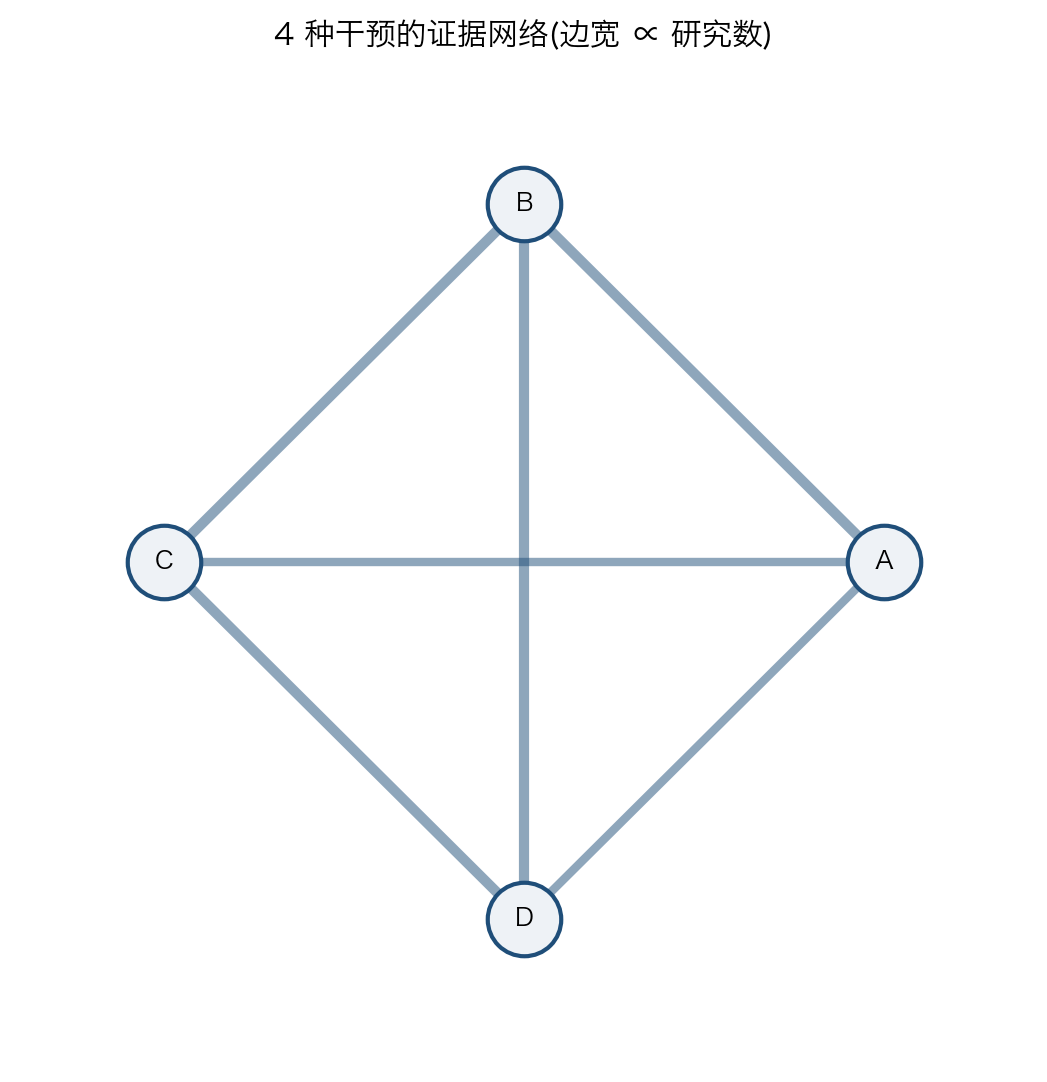

In [12]:
sv.pl.netgraph(study, out="fig26_netgraph.png", title="4 种干预的证据网络(边宽 ∝ 研究数)")
Image("fig26_netgraph.png")

## 10. League table heatmap: sv.pl.netheat

**Problem solved**: visualize the complete-pairwise league table at a glance—each cell is the pooled log-OR for "row treatment vs column treatment", color-coded for direction and magnitude. **Steps**: extract treatment effects from `models["nma"]`, take differences to get the all-pairs matrix, heatmap it. For a consistent network, this matrix should cleanly reflect the D > C > B > A hierarchy (D vs A most red / largest).

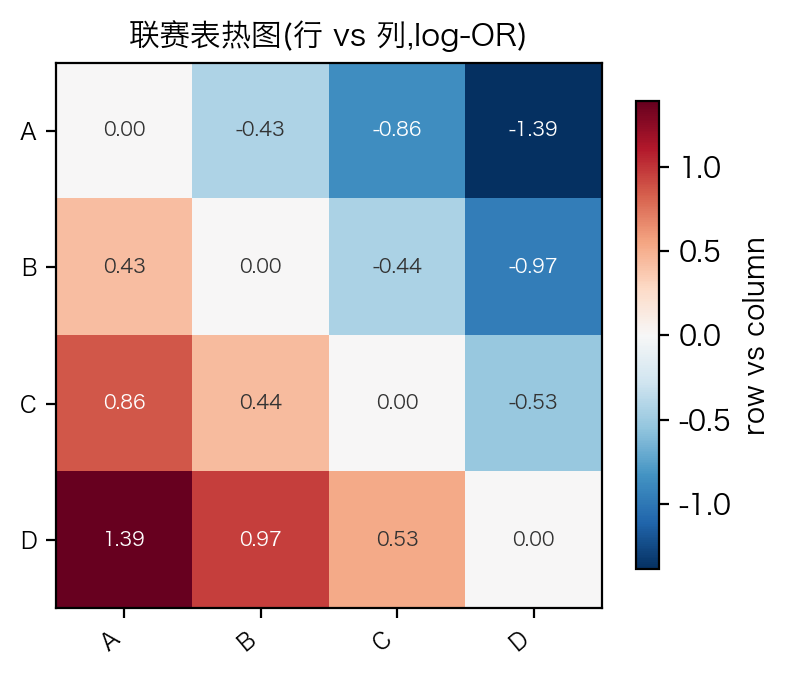

In [13]:
sv.pl.netheat(study, out="fig26_netheat.png", title="联赛表热图(行 vs 列,log-OR)")
Image("fig26_netheat.png")

## Summary: a reproducible evidence trail

We completed frequentist network meta-analysis on a **consistent network**, with every step recorded in `StudyState` and every number traceable to its `sv.*` function, confirming the network **recovers the true value** (D vs A ≈ 1.5) and shows **no** direct/indirect conflict:

```
arm-level table ──sv.pp.nma_pairwise──▶ contrast data (log-OR + intra-cluster covariance)
       ──sv.tl.netmeta(GLS, random)──▶ all treatment effects + league table (D vs A ≈ +1.5, recovers true value)
       ──sv.tl.netrank / nma_rankogram──▶ ranking D > C > B > A (P-score / SUCRA concordant)
       ──sv.tl.nma_inconsistency──▶ between-design inconsistency Q not significant
       ──sv.tl.netsplit──▶ per-comparison direct ≈ indirect, 0 conflicts
       ──sv.tl.netcomb──▶ component additive effects (relabeling demo: b/c/d recover +0.5/+1.0/+1.5)
       ──sv.pl.netgraph / netheat──▶ network geometry + league table heatmap
```

**Key points**: network meta lets you leverage all direct + indirect evidence and rank all interventions at once, but **consistency is a prerequisite**—before ranking, you must use global Q decomposition + node splitting to check whether direct/indirect evidence conflict; report rankings using P-score/SUCRA, not just point-estimate ranks. Frequentist contrast method (this notebook) and Bayesian `gemtc` results typically agree closely, and this method is **exact, requiring no MCMC tuning**. The next notebook moves to **diagnostic accuracy meta-analysis** (bivariate model + SROC), a pooling approach for different outcome types (sensitivity/specificity).